# 11.9 裁切後，模型還收得到作答線索嗎？


紅方塊靠在原圖右邊，中心裁切只留下一條紅色窄帶。問顏色可能仍有線索，問完整形狀卻可能缺資料。先看前處理後的圖，再判斷是哪一段出問題。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

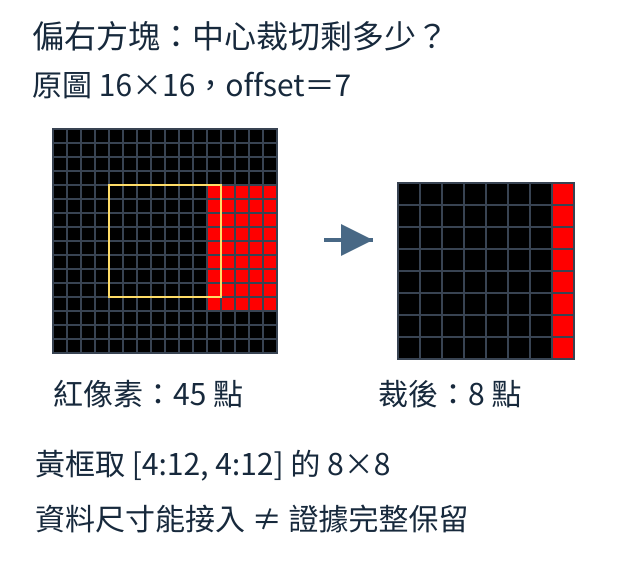

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-11-crop-evidence.svg")))

In [3]:
from tiny_perceptron.multimodal import scene

image = scene("red", "square", offset=7)
crop = image[:, 4:12, 4:12]
print("原圖形狀", tuple(image.shape), "裁切形狀", tuple(crop.shape))
print("原圖紅色格", int((image[0] > 0).sum()))
print("裁切紅色格", int((crop[0] > 0).sum()))

原圖形狀 (3, 16, 16) 裁切形狀 (3, 8, 8)
原圖紅色格 45
裁切紅色格 8


原圖 `(3,16,16)`，裁切 `(3,8,8)`，紅通道亮格從 45 成 8。切片 `4:12` 取索引 4–11；方塊中心橫索引 15，本來就超出右界一部分，所以原圖也不是完整 81 格。

圖中的框是實際裁切範圍，不是模型自動找出的物件。補空白或放大可以恢復入口尺寸，卻不能還原被切掉的像素。縮圖則是把較多像素合成較少像素，也可能把小字與背景混在一起。

既有裁切介入後，十二題仍答對九題（9/12），不能說資訊無損：殘留色帶仍能辨色，而形狀原先就一律猜 circle。原本不會辨形狀的測試，無法顯示裁切造成多少形狀退步。

排錯時保存原圖、裁切設定與處理後圖。若目標完全消失，答案也應允許看不見，不能強迫用原圖真值猜。練習把 offset 改 0，原紅格 81、中心裁切紅格 64；這次只改前處理材料，沒有改變模型。

<details>
<summary>回顧與查證</summary>

可回顧：[10.1像素與坐標](https://birdhackor.github.io/tiny-perceptron-vlm/10.1.html)。

原實驗的資料切分、更新設定與逐題結果見[既有實報](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/vision_ablation.json)；重做入口見[實驗說明](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/README.md)。這是上述有限任務的歷史紀錄。

</details>
